In [1]:
import sys
sys.path.append('src')
from satpos import *
from RINEX import *
from sppp import *
from brdc_pro import *

### This is a Jupyter Notebook of pseudo-range differential GNSS (DGNSS) of Easy4RTK, including RTK processing, results saving and visualization.   

In [2]:
def reconstruct_obs_mat(obs_mat):
    #函数: 重整有效观测数据字典(根据Epoch_OK标识)
    #输入: 有效观测数据字典
    #输出: 重整后的观测数据字典
    r_obsmat=[]
    for i in range(len(obs_mat)):
        if(obs_mat[i][0]['Epoch_OK'])!=0:
            continue
        else:
            r_obsmat.append(obs_mat[i])
    #返回观测数据字典
    return r_obsmat
def check_dgnss_mats(obs_mats):
    #函数: 校验多系统观测值匹配性
    #输入: 多系统观测值列表
    #输出: 观测值数据
    lens=[]
    for i in range(len(obs_mats)):
        lens.append(len(obs_mats[i]))
    #列表仅单值
    if(lens==1):
        print("Only one system observed")
        return True
    #列表有多系统观测
    for i in range(len(lens)-1):
        if(lens[i]!=lens[i+1]):
            print("Observations among systems not equal")
            return False
    #长度校验通过, 开始时间校验
    for i in range(len(obs_mats[0])):
        GPS_week=obs_mats[0][i][0][0]["GPSweek"]
        GPS_sec=obs_mats[0][i][0][0]["GPSsec"]
        for j in range(len(obs_mats)):
            check_week=obs_mats[j][i][0][0]['GPSweek']
            check_sec=obs_mats[j][i][0][0]['GPSsec']
            if(check_week!=GPS_week or check_sec!=GPS_sec):
                print("Observations among systems not in the same time period")
                return False
    
    #全部校验通过, 返回True
    return True

### 1. The block below is configurations of Easy4RTK-DGNSS mode

In [3]:
#首先读取观测值(以RINEX后处理文件模型为例)
base_path='data/OBS/HKCORS/hkkt1320.24o'
base_pos=[-2405144.7839135155, 5385195.185859677, 2420032.321928919]       #基准站坐标
rove_path='data/OBS/HKCORS/hksc1320.24o'
obs_types=[['C1C','L1C','D1C','S1C','XXX','XXX','XXX','XXX'],              #设置参与解算的码点
           ['C1I','L1I','D1I','S1I','C7I','L7I','D7I','S7I']               #差分GNSS仅支持单频解算
           ]
sys_index=['G','C']                                                        #系统选择, 支持多系统

dy_mode='static'                                                            #解算模式, 静态/动态

eph_path='data/BRDC/brdc1320.24p'                                           #广播星历文件
atx_path='data/ATX/igs20.atx'                                               #天线文件

eph_mode='brdc'                                                             #DGNSS仅支持广播星历
clk_mode='brdc'                                                             #DGNSS仅支持广播钟差

el_threthod=10.0                                                            #截止高度角
ex_threshold_v=30.0                                                         #先验残差阈值(m)
exthreshold_v_sigma=4.0                                                     #后验残差阈值(倍数)
dsnr_threshold=None                                                         #单差SNR随机模型

out_age=31                                                                  #最大失锁秒数容限

freqs=[[1575.42e6,0e6],                                                     #频率
       [1561.098e6,1207.14e6]
       ]

sat_out=[]                                                                  #排除卫星列表

epoch_start=0                                                               #起始历元
epoch_length=2880                                                           #解算历元长度

#广播星历读取
ion_parmas_GPSK,GPS_eph=BRDC2GPSEPH(eph_path)
ion_parmas_BDSK,BDS_eph=BRDC2BDSEPH(eph_path)
ion_parmas_GAL,GAL_eph=BRDC2GALEPH(eph_path)

ion_param=ion_parmas_GPSK

#观测值读取与重整

#读取基准站多系统数据
br_obs_mats=[]
for sys in sys_index:
    f_sys=sys_index.index(sys)#观测系统索引
    base_obs_mat=reconstruct_obs_mat(RINEX3_to_obsmat(base_path,obs_types[f_sys],sys=sys,f1=freqs[f_sys][0],f2=freqs[f_sys][1]))
    base_time_list=[t[0]['GPSsec'] for t in base_obs_mat]
    rove_obs_mat=reconstruct_obs_mat(RINEX3_to_obsmat(rove_path,obs_types[f_sys],sys=sys,f1=freqs[f_sys][0],f2=freqs[f_sys][1]))
    rove_time_list=[t[0]['GPSsec'] for t in rove_obs_mat]
    #RTK
    br_obs_mat=[]
    for i in range(len(rove_time_list)):
        br_obs_mat.append([[],[]]) 
        try:
            id_base=base_time_list.index(rove_time_list[i])
        except:
            continue
        br_obs_mat[-1][0]=base_obs_mat[id_base].copy()
        br_obs_mat[-1][1]=rove_obs_mat[i].copy()
    br_obs_mats.append(br_obs_mat.copy())
del br_obs_mat
#多系统观测值的校验(多系统观测值维度说明: 系统, 历元, 基准/流动站, 观测值mat)
multi_GNSS_YES=check_dgnss_mats(br_obs_mats)
if(not multi_GNSS_YES):
        ValueError("Muti-GNSS Observations Not Valid")

No XXX
No XXX
No XXX
No XXX
No XXX
No XXX
No XXX
No XXX


### 2. The blocks below are used as the main processing of DGNSS

In [4]:
#初始化差分GNSS状态量
def init_DGNSS_M(base_pos,br_obs_mats,index,eph_mode="brdc",spp_brdc=[],brdc_obs=[]):
    #首先初始化流动站位置
    if(eph_mode=='brdc'):
        rove_rr=spp_brdc.copy()
    else:
        return False
    rt_week=br_obs_mats[0][index][1][0]['GPSweek']#维数: 系统/历元/站类型/观测mat
    rt_sec=br_obs_mats[0][index][1][0]['GPSsec']
    rt_unix=gpst2time(rt_week,rt_sec)
    sys_sat_nums=[32,65,37]
    #初始化全系统状态量内存空间
    sys_sat_num=sum(sys_sat_nums)
    X=np.zeros((5+3*sys_sat_num,1),dtype=np.float64)
    Pk=np.zeros((5+3*sys_sat_num,5+3*sys_sat_num),np.float64)
    Qk=np.zeros((5+3*sys_sat_num,5+3*sys_sat_num),np.float64)
    X_time=np.zeros((5+3*sys_sat_num,1))
    X[0][0],X[1][0],X[2][0],X[3][0],X[4][0]=rove_rr[0],rove_rr[1],rove_rr[2],0.15,0.15#扩展卡尔曼滤波, 直接给出流动站位置
    Pk[0][0],Pk[1][1],Pk[2][2]=30*30,30*30,30*30
    Pk[3][3],Pk[4][4]=0.3**2,0.3**2 #初始化对流层湿延迟偏差方差为 0.3m
    X_time[0][0],X_time[1][0],X_time[2][0],X_time[3][0],X_time[4][0]=rt_unix,rt_unix,rt_unix,rt_unix,rt_unix
    
    return X,X_time,Pk,Qk

def select_ddsat_dgnss_M(base_obs,rove_obs,base_pos,rove_pos,rt_unix,sys_index,freqs,eph_mode='sp3',IGS=[],clk=[],GPS_eph=[],BDS_eph=[],GAL_eph=[],base_satpos_pre={},rove_satpos_pre={},dsnr_threshold=None,rnx_sdobs_pre=[]):
    #以流动站为基准,创建站间单差观测矩阵(同时消去卫星钟差、ZHD和卫地距项) 
    OMGE=7.2921151467E-5
    rnx_sdobs=[]
    base_prns=[t['PRN'] for t in base_obs]
    rove_prns=[t['PRN'] for t in rove_obs]
    pre_prns=[t['PRN'] for t in rnx_sdobs_pre]
    base_satpos={}
    rove_els={}
    for prn in rove_prns:
        if(len(pre_prns) and prn not in pre_prns):
            continue
        if(prn not in rove_prns):
            continue
        try:
            id_base=base_prns.index(prn)
        except:
            continue
        id_rove=rove_prns.index(prn)
        sdobs=[0.0,0.0,0.0,0.0,0.0]
        #循环构建站间单差观测值(无值不单差)
        sat_use_sign=1
        for obs in range(5):
            #判断流动站和基准站观测值是否非法
            if(base_obs[id_base]['OBS'][obs]!=0.0 and rove_obs[id_rove]['OBS'][obs]!=0.0):
                if(obs==0 or obs==5):
                    #伪距观测值的计算值
                    p_b=base_obs[id_base]['OBS'][obs]#基准站伪距
                    if(base_satpos_pre!={}):
                        rs_b,dts_b=base_satpos_pre[prn],base_satpos_pre[prn][3]
                    elif(base_satpos_pre=={} and eph_mode=='brdc'):
                        #广播星历计算卫星位置
                        if(prn[0]=='G'):
                            rs_info=GPSEPH2Satpos(GPS_eph,rt_unix,prn,rho=p_b)
                            rs_b,dts_b=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='C'):
                            rs_info=BDSEPH2SatPos(BDS_eph,rt_unix,prn,rho=p_b)
                            rs_b,dts_b=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='E'):
                            rs_info=GALEPH2Satpos(GAL_eph,rt_unix,prn,rho=p_b)
                            rs_b,dts_b=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                    r0_b=sqrt( (rs_b[0]-base_pos[0])*(rs_b[0]-base_pos[0])+(rs_b[1]-base_pos[1])*(rs_b[1]-base_pos[1])+(rs_b[2]-base_pos[2])*(rs_b[2]-base_pos[2]) )
                    r0_b=r0_b+OMGE*(rs_b[0]*base_pos[1]-rs_b[1]*base_pos[0])/clight
                    Mh,_=NMF(base_pos,rs_b,rt_unix)
                    zhd=get_Trop_delay_dry(base_pos)
                    p_b_osr=p_b-(r0_b+Mh*zhd-clight*dts_b)#基准站伪距的计算值
                    base_satpos[prn]=[rs_b[0],rs_b[1],rs_b[2],dts_b,rs_b[3],rs_b[4],rs_b[5],999.0]

                    p_r=rove_obs[id_rove]['OBS'][obs]#流动站伪距
                    if(rove_satpos_pre!={}):
                        rs_r,dts_r=rove_satpos_pre[prn],rove_satpos_pre[prn][3]
                    elif(rove_satpos_pre=={} and eph_mode=='brdc'):
                         #广播星历计算卫星位置
                        if(prn[0]=='G'):
                            rs_info=GPSEPH2Satpos(GPS_eph,rt_unix,prn,rho=p_r)
                            rs_r,dts_r=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='C'):
                            rs_info=BDSEPH2SatPos(BDS_eph,rt_unix,prn,rho=p_r)
                            rs_r,dts_r=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                        if(prn[0]=='E'):
                            rs_info=GALEPH2Satpos(GAL_eph,rt_unix,prn,rho=p_r)
                            rs_r,dts_r=[rs_info[0],rs_info[1],rs_info[2],rs_info[4],rs_info[5],rs_info[6]],rs_info[3]
                    r0_r=sqrt( (rs_r[0]-rove_pos[0])*(rs_r[0]-rove_pos[0])+(rs_r[1]-rove_pos[1])*(rs_r[1]-rove_pos[1])+(rs_r[2]-rove_pos[2])*(rs_r[2]-rove_pos[2]) )
                    r0_r=r0_r+OMGE*(rs_r[0]*rove_pos[1]-rs_r[1]*rove_pos[0])/clight
                    Mh,_=NMF(rove_pos,rs_r,rt_unix)
                    zhd=get_Trop_delay_dry(rove_pos)
                    p_r_osr=p_r-(r0_r+Mh*zhd-clight*dts_r)#流动站伪距的计算值
                    sdobs[obs]=p_b_osr-p_r_osr#伪距站间单差
                    rove_els[prn]=getazel(rs_r,rove_pos)[1]
                elif(obs==1 or obs==6):
                    #载波相位观测值的频率确定
                    if(obs==1):
                        f=freqs[sys_index.index(prn[0])][0]
                    if(obs==6):
                        f=freqs[sys_index.index(prn[0])][1]
                    #载波相位观测值的站间单差
                    l_b=clight/f*base_obs[id_base]['OBS'][obs]#基准站载波相位
                    Mh,_=NMF(base_pos,rs_b,rt_unix)
                    zhd=get_Trop_delay_dry(base_pos)
                    l_b_osr=l_b-(r0_b+Mh*zhd-clight*dts_b)           #基准站载波相位的计算值

                    l_r=clight/f*rove_obs[id_rove]['OBS'][obs]#流动站载波相位
                    Mh,_=NMF(rove_pos,rs_r,rt_unix)
                    zhd=get_Trop_delay_dry(rove_pos)
                    l_r_osr=l_r-(r0_r+Mh*zhd-clight*dts_r)#流动站伪距的计算值
                    sdobs[obs]=l_b_osr*f/clight-l_r_osr*f/clight#载波相位间单差
                else:#其余导航状态直接单差(引入站间单差模型, 考虑一种新的基于dSNR的站间单差模型)
                    sdobs[obs]=base_obs[id_base]['OBS'][obs]-rove_obs[id_rove]['OBS'][obs]
            #观测值有效性校验(伪距差分只考虑伪距有效性)
            if( obs in [0,5] and (base_obs[id_base]['OBS'][obs]==0.0 or rove_obs[id_rove]['OBS'][obs]==0.0) ):
                sat_use_sign=0
            #单差SNR掩码模型有效性
            if(dsnr_threshold!=None and obs in [4,9] and abs(sdobs[obs])>dsnr_threshold):
                sat_use_sign=0
        if(sat_use_sign):
            rnx_sdobs.append({'PRN':prn,'OBS':sdobs.copy()})
    return rnx_sdobs,base_satpos,rove_els

def update_DGNSS_state_M(spp_rr,epoch,rt_unix,X,X_time,Qk,dy_mode):
    #首历元, 跳过状态更新
    if(not epoch):
        return 
    #提取总卫星数量
    sat_num=round((len(X)-5)/3)
    #基线向量状态更新
    if(dy_mode=='static'):
        #静态, 无过程噪声
        Qk[0][0],Qk[1][1],Qk[2][2]=0.0,0.0,0.0
    else:
        #动态, 有过程噪声
        X[0][0],X[1][0],X[2][0]=spp_rr[0],spp_rr[1],spp_rr[2]
        Qk[0][0],Qk[1][1],Qk[2][2]=30*30,30*30,30*30
    #基准站天顶对流层湿延迟状态更新
    dt=rt_unix-X_time[3][0]
    Qk[3][3]=1e-8*dt
    #流动站对流层湿延迟状态更新
    dt=rt_unix-X_time[4][0]
    Qk[4][4]=1e-8*dt

#获得单个系统的最高高度角参考星
def get_ref_elmax(rnx_sdobs,rove_satpos,rr,target_sys='G'):
    #分系统参考星选择
    el_max,el_max_id,el_scan_id=0,999,0
    for sat in [t['PRN'] for t in rnx_sdobs]:
        if(sat[0]!=target_sys):
            el_scan_id+=1
            continue
        _,el=getazel(rove_satpos[sat],[rr[0],rr[1],rr[2]])
        if(el>el_max):
            el_max=el
            el_max_id=el_scan_id
        el_scan_id+=1
    return el_max,el_max_id


def create_DGNSS_HRZ_M(rnx_sdobs,base_pos,X,rt_unix,rove_satpos,sys_index,freqs,ex_threshold_v=30,exthreshold_v_sigma=4,post=False):
    #初始化卫星数量
    sat_num=len(rnx_sdobs)
    sat_out=[]
    sat_out_post=[]

    #流动站坐标、接收机钟差
    rr=np.array([X[0],X[1],X[2],X[3]]).reshape(4)

    #逐系统获取参考卫星
    el_max_G,el_max_id_G=get_ref_elmax(rnx_sdobs,rove_satpos,rr,'G')
    el_max_C,el_max_id_C=get_ref_elmax(rnx_sdobs,rove_satpos,rr,'C')
    el_max_E,el_max_id_E=get_ref_elmax(rnx_sdobs,rove_satpos,rr,'E')
    el_max_ids=[el_max_id_G,el_max_id_C,el_max_id_E]
    #计算有效观测系统数量
    sys_access=0
    for t in el_max_ids:
        if(t!=999):
            sys_access+=1
    #创建设计矩阵和观测值矩阵(RTK扩展双差观测模型,: 状态维数4+3n, 观测维数: 4(n-sysnum) )
    state_num,observation_num=3,(sat_num-sys_access)
    H=np.zeros((observation_num,state_num),dtype=np.float64)        #设计矩阵 观测×状态
    R=np.zeros((observation_num,observation_num),dtype=np.float64)  #观测方差 观测×观测
    Z=np.zeros((observation_num,1),dtype=np.float64)                #观测矩阵 状态×状态
    Z_scan_count=0
    #单卫星四行矩阵创建与校区
    for i in range(len(rnx_sdobs)):
        #如果为参考星, 跳过
        if(i in el_max_ids):
            continue
        #PRN号识别
        si_PRN,sys_id=rnx_sdobs[i]["PRN"],sys_index.index(rnx_sdobs[i]["PRN"][0])
        si_PRN_ref=rnx_sdobs[el_max_ids[['G','C','E'].index(si_PRN[0])]]['PRN']
        sys_shift=[0,32,32+65][['G','C','E'].index(si_PRN[0])]
        #本卫星所属系统参考星索引位置
        el_max_id=el_max_ids[['G','C','E'].index(si_PRN[0])]
        #几何距离计算
        rs=rove_satpos[si_PRN]
        rs_ref=rove_satpos[si_PRN_ref]
        r0=sqrt( (rs[0]-rr[0])*(rs[0]-rr[0])+(rs[1]-rr[1])*(rs[1]-rr[1])+(rs[2]-rr[2])*(rs[2]-rr[2]) )
        r0_ref=sqrt( (rs_ref[0]-rr[0])*(rs_ref[0]-rr[0])+(rs_ref[1]-rr[1])*(rs_ref[1]-rr[1])+(rs_ref[2]-rr[2])*(rs_ref[2]-rr[2]) )
        #单差方向余弦向量计算
        urs_dx=-(rr[0]-rs[0])/r0 + (rr[0]-rs_ref[0])/r0_ref
        urs_dy=-(rr[1]-rs[1])/r0 + (rr[1]-rs_ref[1])/r0_ref
        urs_dz=-(rr[2]-rs[2])/r0 + (rr[2]-rs_ref[2])/r0_ref
        #频率提取
        f1,f2=freqs[sys_id][0],freqs[sys_id][1]
        #p1双差伪距法方程
        H_sub_1=np.zeros(3,dtype=np.float64)
        H_sub_1[:]=[urs_dx,urs_dy,urs_dz]
        #设计矩阵
        H[Z_scan_count]=H_sub_1
        #残差向量(双差观测值,单位为m)
        Z[Z_scan_count]=rnx_sdobs[i]['OBS'][0]-rnx_sdobs[el_max_id]['OBS'][0]
        # #流动站观测噪声(随机模型)
        _,el=getazel(rs,rr)                                           #流动站卫星高度角
        _,el_ref=getazel(rs_ref,rr)                                   #流动站参考卫星高度角
        var=0.003*0.003+0.003*0.003/sin(el)/sin(el)                   #流动站载波相位噪声
        var_ref=0.003*0.003+0.003*0.003/sin(el_ref)/sin(el_ref)       #流动站参考卫星载波相位噪声
        #基准站观测噪声(随机模型)
        _,el_b=getazel(rs,base_pos)                                   #基准站卫星高度角
        _,el_b_ref=getazel(rs_ref,base_pos)                           #基准站参考卫星高度角
        var_b=0.003*0.003+0.003*0.003/sin(el_b)/sin(el_b)             #基准站载波相位噪声
        var_b_ref=0.003*0.003+0.003*0.003/sin(el_b_ref)/sin(el_b_ref) #基准站参考卫星载波相位噪声
        # #双差随机模型
        R[Z_scan_count][Z_scan_count]=100*100*(var+var_ref+var_b+var_b_ref)
        #验前残差粗差识别
        if(post==False):
            if(abs(Z[Z_scan_count])>ex_threshold_v):
                #非首历元粗差剔除
                print(si_PRN,"Outlier for Preresiduals",Z[Z_scan_count][0])
                sat_out.append(i)#注意: 此处必须添加观测列表中的id索引             
        #验后方差校验
        if(post==True):
            out_v=[]
            if abs(Z[Z_scan_count])>exthreshold_v_sigma*sqrt(R[Z_scan_count][Z_scan_count]): 
                #print(si_PRN," 验后方差校验不通过",v[i*4],4*sqrt(R[i*4][i*4]))
                out_v.append(Z[Z_scan_count])
            if(len(out_v)):
                out_v.append(i)
                sat_out_post.append(out_v)
        
        Z_scan_count+=1
    #循环结束, 处理验前/验后粗差
    #验前残差部分
    obslist_new=rnx_sdobs.copy()
    for s in sat_out:
        obslist_new.remove(rnx_sdobs[s])
    #验后残差部分
    if(post==True):
        #全部校验通过
        if(len(sat_out_post)==0):
            return "KF fixed", obslist_new,Z,el_max_ids
        #找到最大残差值
        vmax=0.0
        v_out=0
        for s in sat_out_post:
            for v_i in range(0,len(s)-1):
                if(abs(s[v_i])>vmax):
                    v_out=s[-1]
                    vmax=s[v_i]
        obslist_new.remove(rnx_sdobs[v_out])
        return "KF fixing", obslist_new,Z,el_max_ids
    return H,R,Z,obslist_new

def createDGNSS_XkPkQk_M(rnx_sdobs,X,Pk,Qk):
    #系统模型构建
    #输入: 观测字典列表, 全局状态X, 全局方差Pk, 全局过程噪声Qk
    #输出: 滤波状态t_Xk, 滤波方差t_Pk, 滤波过程噪声t_Qk
    
    #本历元更新状态所用系统临时变量(依据: 在观测列表内的卫星数量)
    t_Xk=np.zeros((3,1),dtype=np.float64)
    t_Pk=np.zeros((3,3),dtype=np.float64)
    t_Qk=np.zeros((3,3),dtype=np.float64)
    
    #有效卫星索引(计算本历元有效卫星各状态量在总状态中的索引)
    index_use=[0,1,2]#基础导航状态

    #系统状态,方差,过程噪声赋值
    for i in range(3):
        t_Xk[i]=X[index_use[i]]                         #系统状态
        t_Qk[i][i]=Qk[index_use[i]][index_use[i]]       #系统过程噪声
        for j in range(3):
            t_Pk[i][j]=Pk[index_use[i]][index_use[j]]   #系统方差
    #返回系统模型各临时矩阵
    return t_Xk,t_Pk,t_Qk

def updateDGNSS_XkPkQk_M(rnx_sdobs,rt_unix,t_Xk,t_Pk,t_Qk,X,Pk,Qk,X_time):
    #系统模型恢复与更新
    #输入: 观测字典列表, 滤波状态t_Xk, 滤波方差t_Pk, 滤波过程噪声t_Qk, 全局状态X, 全局方差Pk, 全局过程噪声Qk
    #输出: 恢复并更新后的全局状态X, 全局方差Pk, 全局过程噪声Qk
    
    #本历元更新状态所用系统临时变量(不能占用全局状态储存空间)
    t_X=np.zeros((3,1),dtype=np.float64)
    t_X_time=np.zeros(3+5,dtype=np.float64)
    t_P=np.zeros((3+5,3+5),dtype=np.float64)
    t_Q=np.zeros((3+5,3+5),dtype=np.float64)
    #拷贝原值
    t_X=X.copy()
    t_X_time=X_time.copy()
    t_P=Pk.copy()
    t_Q=Qk.copy()
    
    index_use=[0,1,2]#基础导航状态

    #系统状态,方差,过程噪声恢复更新
    for i in range(3):
        t_X[index_use[i]]=t_Xk[i]                         #系统状态
        t_X_time[index_use[i]]=rt_unix                    #系统状态时标
        t_Q[index_use[i]][index_use[i]]=t_Qk[i][i]        #系统过程噪声
        for j in range(3):
            if(i==j and t_Pk[i][j]<0.0):
                t_Pk[i][j]=30*30
            t_P[index_use[i]][index_use[j]]=t_Pk[i][j]   #系统方差
    #返回系统模型各全局矩阵
    return t_X,t_P,t_Q,t_X_time

def log2dgnssout(rt_unix,v,obslist,X,Pk,peph_sat_pos,ref_sat_ids,freqs):
    #历元数据整备
    out={}
    v_id=0
    for i in range(len(obslist)):
        if(i in ref_sat_ids):
            continue
        si_PRN=obslist[i]['PRN']
        ref_PRN=obslist[ref_sat_ids[['G','C','E'].index(si_PRN[0])]]['PRN']

        # p1=obslist[i]['OBS'][0]
        # l1=obslist[i]['OBS'][1]
        # s1=obslist[i]['OBS'][4]
        # p2=obslist[i]['OBS'][5]
        # l2=obslist[i]['OBS'][6]
        # s2=obslist[i]['OBS'][9]
        # print(p1,p2,phi1,phi2)
        
        #卫星位置
        rs=[peph_sat_pos[si_PRN][0],peph_sat_pos[si_PRN][1],peph_sat_pos[si_PRN][2],peph_sat_pos[si_PRN][3]]

        out[si_PRN]={}
        out[si_PRN]['GPSweek'],out[si_PRN]['GPSsec']=satpos.time2gpst(rt_unix)
        
        out[si_PRN]['sat_x']=rs[0]
        out[si_PRN]['sat_y']=rs[1]
        out[si_PRN]['sat_z']=rs[2]
        out[si_PRN]['sat_cdt']=satpos.clight*rs[3]

        out[si_PRN]['sta_x']=X[0][0]
        out[si_PRN]['std_sta_x']=Pk[0][0]
        out[si_PRN]['sta_y']=X[1][0]
        out[si_PRN]['std_sta_y']=Pk[1][1]
        out[si_PRN]['sta_z']=X[2][0]
        out[si_PRN]['std_sta_z']=Pk[2][2]
        out[si_PRN]['GPSsec_dt']=X[3][0]
        out[si_PRN]['std_GPSsec_dt']=Pk[3][3]

        rr=[X[0][0],X[1][0],X[2][0]]
        out[si_PRN]['ztd_h']=get_Trop_delay_dry(rr)
        out[si_PRN]['ztd_w']=get_Tropdelay(rr,rs)-out[si_PRN]['ztd_h']
        out[si_PRN]['res_p1']=v[v_id][0]

        az,el=getazel(rs,rr)
        out[si_PRN]['azel']=[az/pi*180.0,el/pi*180.0]

        v_id+=1
    return out


In [5]:
epoch=0
Out_log=[]      #DGNSS结果存储列表
Out_log_spp=[]  #SPP结果存储列表

#逐历元遍历
for i in tqdm(range(epoch_start,epoch_start+epoch_length)):
    if(i>=len(br_obs_mats[0])):
        #如果目标索引超过总观测历元长度
        break
    #从多模观测值中获取单历元流动站单站组合观测值
    rover_spp_M_mat,base_spp_M_mat=[],[]
    for sys_id in range(len(sys_index)):
            rover_spp_M_mat.append([br_obs_mats[sys_id][i][1]])
            base_spp_M_mat.append([br_obs_mats[sys_id][i][0]])
    #初始化状态向量
    if(epoch==0):
        rove_rr,rove_obs,rove_satpos=SPPM_form_BRDC(rover_spp_M_mat,0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod)
        X,X_time,Pk,Qk=init_DGNSS_M(base_pos,br_obs_mats,i,eph_mode='brdc',spp_brdc=rove_rr,brdc_obs=rove_obs)
        epoch+=1
    #记录流动站当前历元时刻
    rt_week=br_obs_mats[0][i][1][0]['GPSweek']
    rt_sec=br_obs_mats[0][i][1][0]['GPSsec']
    rt_unix=gpst2time(rt_week,rt_sec)
    #对流动站进行SPP
    rove_rr,rove_obs,rove_satpos=SPPM_form_BRDC(rover_spp_M_mat,0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod)
    #对基准站进行观测列表求解/SPP求解
    base_obs,base_satpos=SPPM_form_BRDC(base_spp_M_mat,0,GPS_eph,BDS_eph,GAL_eph,sat_out,ion_param,'SF',freqs,el_threthod,out_mode='Sat only')
    Out_log_spp.append({'G01':{'GPSweek':rt_week,'GPSsec':rt_sec,'sta_x':rove_rr[0],'sta_y':rove_rr[1],'sta_z':rove_rr[2],'GPSsec_dt':0,'ztd_w':0,'ztd_h':0}})
    if(len(rove_obs)<4):
        print("No valid observation, Pass Week: {}, Sec: {}.".format(rt_week,rt_sec))
        continue
    # #状态更新(包括选取可视卫星单差观测值和状态量更新) 
    if(dy_mode=='static'):
        rove_rr=[X[0][0],X[1][0],X[2][0]]
    rnx_sdobs,base_satpos,rove_els=select_ddsat_dgnss_M(base_obs,rove_obs,base_pos,rove_rr,rt_unix,sys_index,freqs,eph_mode='brdc',base_satpos_pre=base_satpos,rove_satpos_pre=rove_satpos,dsnr_threshold=dsnr_threshold)
    
    update_DGNSS_state_M(rove_rr,epoch,rt_unix,X,X_time,Qk,dy_mode)
    epoch+=1
    #卡尔曼滤波迭代
    for KF_times in range(8):
        #构建法方程(观测模型)
        H,R,v,rnx_sdobs=create_DGNSS_HRZ_M(rnx_sdobs,base_pos,X,rt_unix,rove_satpos,sys_index,freqs,ex_threshold_v=ex_threshold_v)#先验排除
        H,R,v,rnx_sdobs=create_DGNSS_HRZ_M(rnx_sdobs,base_pos,X,rt_unix,rove_satpos,sys_index,freqs,ex_threshold_v=ex_threshold_v)#先验排除
        #构建系统模型(从大状态向量X, Pk, Qk中获得本历元优化状态模型)
        t_Xk,t_Pk,t_Qk=createDGNSS_XkPkQk_M(rnx_sdobs,X,Pk,Qk)
        #卡尔曼滤波
        #扩展卡尔曼滤波
        #1.状态一步预测
        PHIk_1_k=np.eye(t_Xk.shape[0],dtype=np.float64)
        X_up=PHIk_1_k.dot(t_Xk)
        #2.状态一步预测误差
        Pk_1_k=(PHIk_1_k.dot(t_Pk)).dot(PHIk_1_k.T)+t_Qk
        #3.滤波增益计算
        Kk=(Pk_1_k.dot(H.T)).dot(inv((H.dot(Pk_1_k)).dot(H.T)+R))
        #Kk=(Pk_1_k.dot(H.T)).dot(numba_inv((H.dot(Pk_1_k)).dot(H.T)+R))
        #滤波结果
        Xk_dot=X_up+Kk.dot(v)
        #滤波方差更新
        t_Pk=((np.eye(t_Xk.shape[0],dtype=np.float64)-Kk.dot(H))).dot(Pk_1_k)  
        t_Pk=t_Pk.dot((np.eye(t_Xk.shape[0],dtype=np.float64)-Kk.dot(H)).T)+Kk.dot(R).dot(Kk.T)
        #滤波暂态更新
        t_Xk_f,t_Pk_f,t_Qk_f,t_X_time=updateDGNSS_XkPkQk_M(rnx_sdobs,rt_unix,Xk_dot,t_Pk,t_Qk,X,Pk,Qk,X_time)
        #验后残差
        #(1)重新组织双差观测
        t_rnx_sdobs,_,_=select_ddsat_dgnss_M(base_obs,rove_obs,base_pos,
                                [t_Xk_f[0][0],t_Xk_f[1][0],t_Xk_f[2][0]],
                                rt_unix,sys_index,freqs,eph_mode='brdc',base_satpos_pre=base_satpos,rove_satpos_pre=rove_satpos,rnx_sdobs_pre=rnx_sdobs,dsnr_threshold=dsnr_threshold)
        #(2)后验残差计算
        info='KF fixed'
        info,t_rnx_sdobs,v,ref_sat_ids=create_DGNSS_HRZ_M(t_rnx_sdobs,base_pos,t_Xk_f,rt_unix,rove_satpos,sys_index,freqs,ex_threshold_v,exthreshold_v_sigma,post=True)
        #(3)主观测列表删除后验残差不通过卫星
        if(info!='KF fixed'):
            t_obs_prns=[t['PRN'] for t in t_rnx_sdobs]
            for obs in rnx_sdobs:
                if(obs['PRN'] not in t_obs_prns):
                    rnx_sdobs.remove(obs)
        if(info=='KF fixed'):
            #验后校验通过
            X,Pk,Qk,X_time=updateDGNSS_XkPkQk_M(rnx_sdobs,rt_unix,Xk_dot,t_Pk,t_Qk,X,Pk,Qk,X_time)
            break
    if(info!='KF fixed'):
        print("Warning: Large Post Residuals make Filter overflow")
    Out_log.append(log2dgnssout(rt_unix,v,rnx_sdobs,X,Pk,rove_satpos,ref_sat_ids,freqs))

  0%|          | 0/2880 [00:00<?, ?it/s]

100%|██████████| 2880/2880 [02:31<00:00, 18.96it/s]


### 3. The block below is used to save the DGNSS results

In [12]:
np.save('nav_result/hkkt_hksc_1320.24o.out.npy',Out_log,allow_pickle=True)      #保存DGNSS解算结果
np.save('nav_result/hksc_spp_1320.24o.out.npy',Out_log_spp,allow_pickle=True)   #保存SPP解算结果

### 4. The blocks below are used to visualize the DGNSS Results

In [7]:
def Log2sta(sol_log):
    # 函数: 将Easy4PPP结果numpy数组转换为定位结果列表
    # function: Transformation between Easy4PPP solution logs to the list of station positions
    # 输入: 结果数组sol_log
    # Input: The numpy array of Easy4PPP solution logs
    # 输出: 定位结果数组[[GPS周, GPS周内秒, 测站ECEF位置X, Y, Z, 测站大地坐标系位置纬度B, 经度L, 椭球高程H]]
    # Output:[[GPS week, GPS second, ECEF-X, ECEF-Y, ECEF-Z, Latitude, Longtitude, Height (Ellipsoidal)]]
    sta=[]
    for i in range(len(sol_log)):
        keys=list(sol_log[i].keys())
        if(not len(keys)):
            continue
        gweek=sol_log[i][keys[0]]['GPSweek']
        gsec=sol_log[i][keys[0]]['GPSsec']
        sta_x=sol_log[i][keys[0]]['sta_x']
        sta_y=sol_log[i][keys[0]]['sta_y']
        sta_z=sol_log[i][keys[0]]['sta_z']
        sta_cdt=sol_log[i][keys[0]]['GPSsec_dt']
        sta_ztd_w=sol_log[i][keys[0]]['ztd_w']
        sta_ztd_h=sol_log[i][keys[0]]['ztd_h']
        sta_b,sta_l,sta_h=xyz2blh(sta_x,sta_y,sta_z)
        sta.append([gweek,gsec,sta_x,sta_y,sta_z,sta_cdt,sta_b,sta_l,sta_h,sta_ztd_w,sta_ztd_h])
    return np.array(sta)

def CRD_SNX2STA(f_name):
    # 函数: 将IGS CRD文件或SNX文件转换为测站基准坐标
    # function: Transformation between IGS SNX or CRD files to the dictionary of station positions
    # 输入: SNX/CRD文件名
    # Input: The path of CRD/SNX file.
    # 输出: 测站基准坐标字典{测站名: [STAX,STAY,STAZ]}
    # Output: {The name of station: [STAX,STAY,STAZ]}
    sta={}
    with open(f_name,"r") as f:
        lines=f.readlines()
        snx_data=[]
        snx_in=0
        now=[0.0,0.0,0.0]
        now_sta="unknown"
        for line in lines:
            if ("+SOLUTION/ESTIMATE" in line):
                snx_in=1
                continue
            if ("-SOLUTION/ESTIMATE" in line):
                snx_in=0
                break

            if(snx_in):
                ls=line.split()
                #排除非位置行
                try:
                    int(ls[0])
                except:
                    continue
                #排除未解除的信息行
                if(ls[1] not in ["STAX","STAY","STAZ"]):
                    continue
                #读取固定解位置结果
                if ls[2]!=now_sta:
                    sta[now_sta]=now.copy()
                    now_sta=ls[2]
                    now=[0.0,0.0,0.0]
                now[["STAX","STAY","STAZ"].index(ls[1])]=float(ls[8])
                #print(line.split())
            else:
                continue
    #最后一个测站
    sta[now_sta]=now.copy()
    
    #矫正天线杆臂
    with open( f_name,"r") as f:
        lines=f.readlines()
        snx_in=0
        for line in lines:
            if ("+SITE/ECCENTRICITY" in line):
                snx_in=1
                continue
            if ("-SITE/ECCENTRICITY" in line):
                snx_in=0
                break
            if(snx_in):
                ls=line.split()
                try:
                    xyz0=sta[ls[0]]
                    dneu=[float(ls[-2]),float(ls[-1]),float(ls[-3])]
                    if(dneu[0]==0.0 and dneu[1]==0.0 and dneu[2]==0.0):
                        continue
                    b0,l0,h0=xyz2blh(xyz0[0],xyz0[1],xyz0[2])
                    R=[[-sin(b0/180*pi)*cos(l0/180*pi), -sin(b0/180*pi)*sin(l0/180*pi), cos(b0/180.0*pi)],
                        [-sin(l0/180*pi),cos(l0/180*pi),0],
                        [cos(b0/180*pi)*cos(l0/180*pi),cos(b0/180*pi)*sin(l0/180*pi),sin(b0/180.0*pi)]]
                    R=np.array(R)
                    R_inv=np.linalg.inv(R)
                    dxyz=(R_inv.dot(np.array(dneu).reshape(3,1))).reshape(3,)
                    xyz0=xyz0+dxyz
                    sta[ls[0]][0]=float(xyz0[0])
                    sta[ls[0]][1]=float(xyz0[1])
                    sta[ls[0]][2]=float(xyz0[2])
                except:
                    pass
                #print(ls)
    #删除无效值
    sta.pop("unknown")
    return sta

First converged in epoch 0


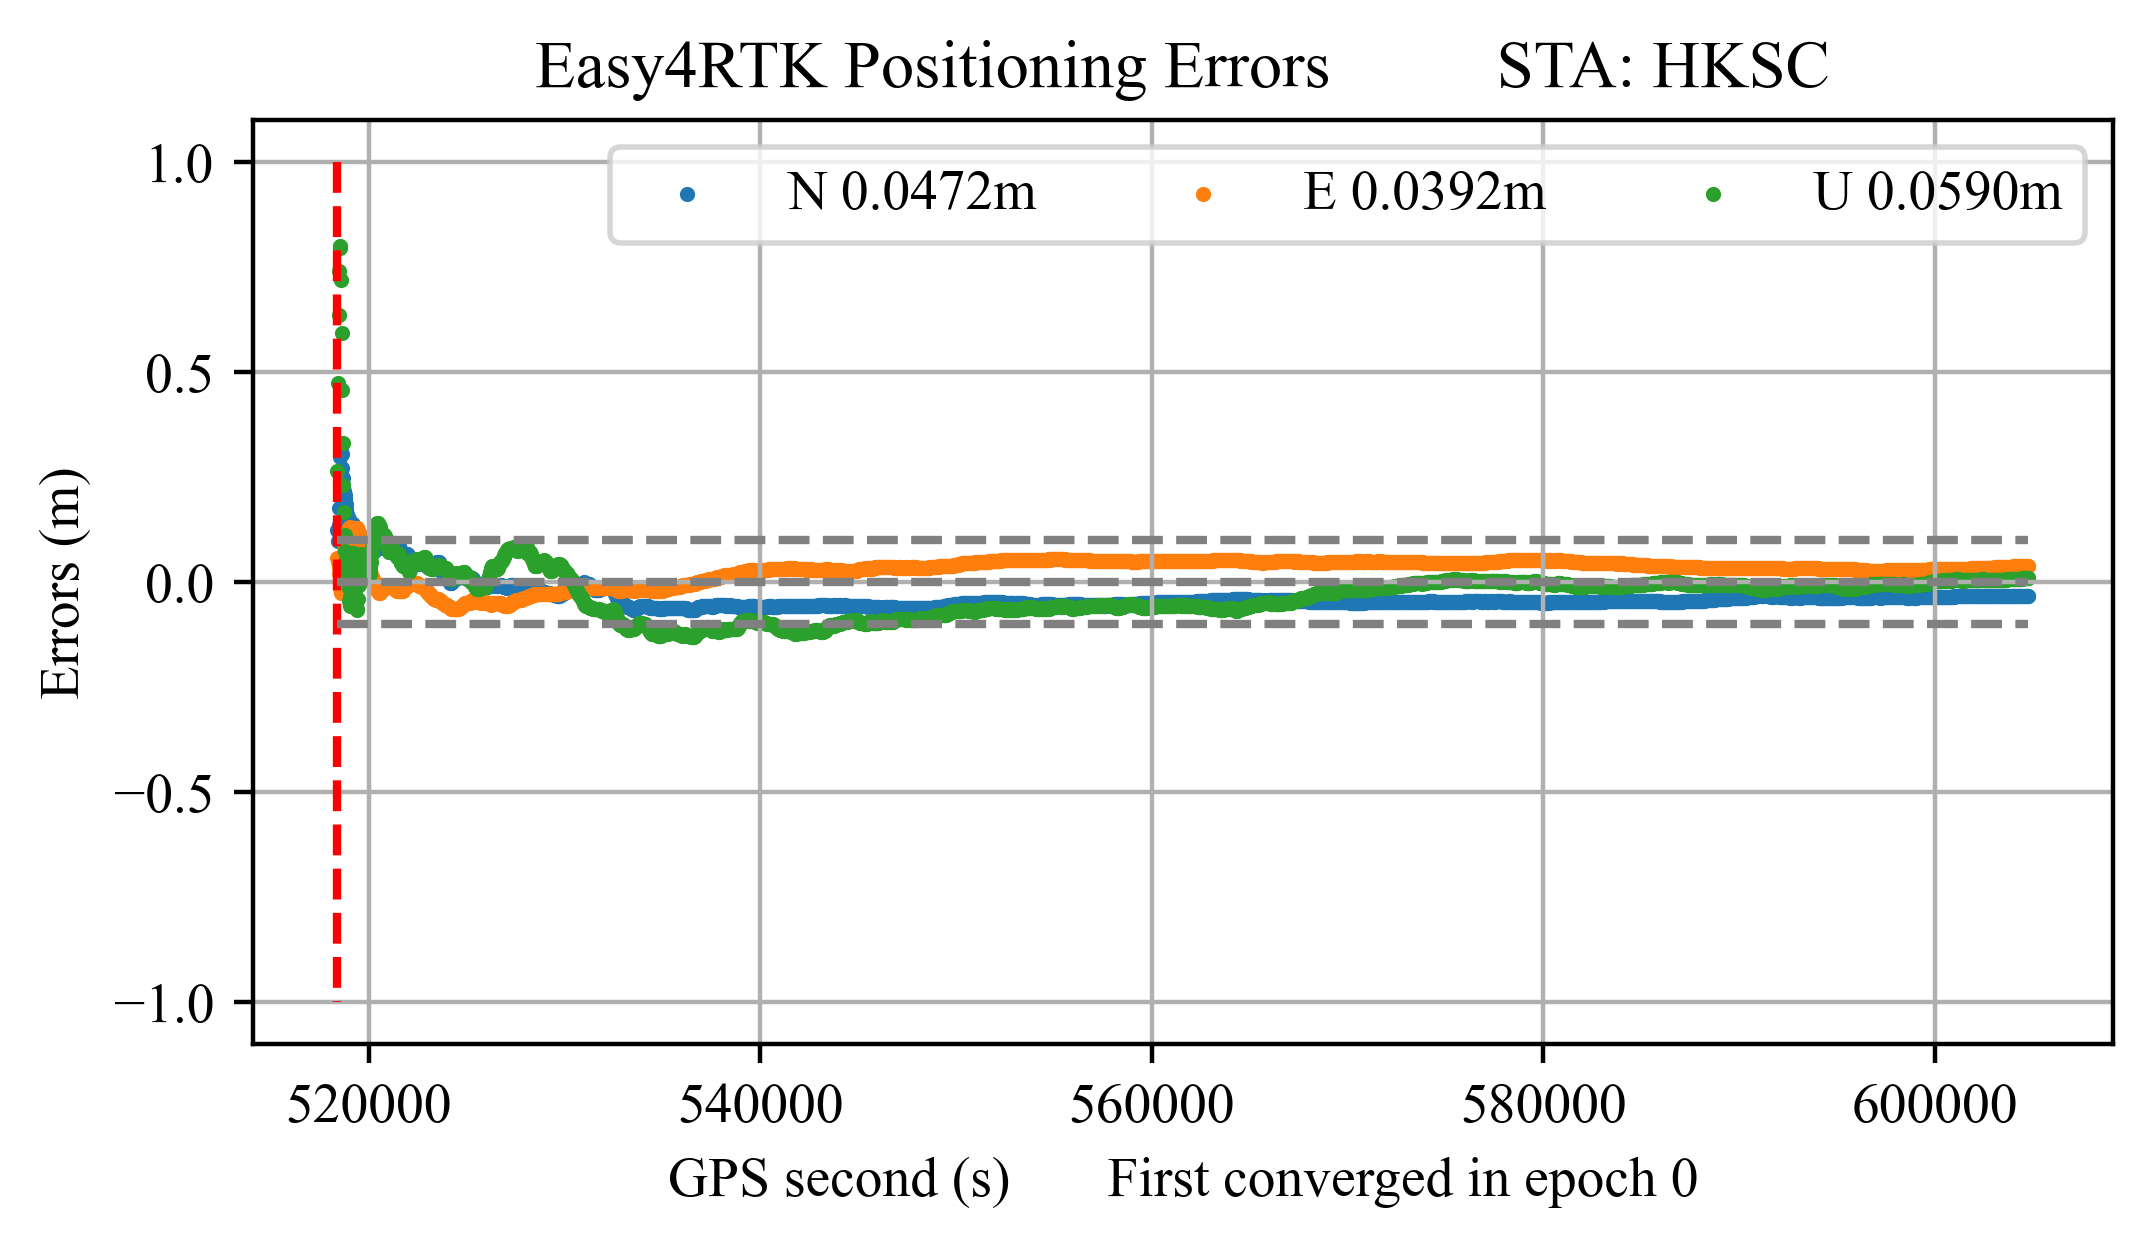

In [8]:
import matplotlib.pyplot as plt

#设置Solution logs文件路径
SNX_CRD_f="data/SNX/IGS0OPSSNX_20241320000_01D_01D_CRD.SNX"
STA_name="HKSC"                                 #解算站点名称, 若空, 自动赋值为解算日志文件的前四位(依据RINEX V3文件命名规则)
ylim=[]                             #误差可视化纵轴范围, 对于PPP而言, ENU误差可视化一般设置为 -1.0m ~ 1.0m 左右较为适宜
STA=[-2414267.8041305584, 5386768.908336419, 2407459.8159006797]
sol_log=Out_log
if(STA==[]):
    STA=CRD_SNX2STA(SNX_CRD_f)[STA_name]
sta=Log2sta(sol_log)
neu=[]
for x in sta:
    neu_x=xyz2neu([x[2],x[3],x[4]],STA)
    neu_n=np.linalg.norm(xyz2neu([x[2],x[3],x[4]],STA))
    neu.append([x[0],x[1],neu_x[0],neu_x[1],neu_x[2],neu_n])
neu=np.array(neu)

#计算首次收敛时间
fix_epoch='failed'
for i in range(len(neu)):
    if((abs(neu[i][2])<=0.30 and abs(neu[i][3])<=0.30)):# and abs(neu[i][4])<=0.10)) or ((neu[i][5])<=0.20)):
        fix_epoch=i
        break
print("First converged in epoch {}".format(fix_epoch))


#绘图
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.figure(dpi=400,facecolor="white",figsize=(6,3))
plt.scatter(neu[:,1],neu[:,2],s=3)
plt.scatter(neu[:,1],neu[:,3],s=3)
plt.scatter(neu[:,1],neu[:,4],s=3)
#plt.plot(neu[:,1],neu[:,5])
plt.grid('on')


#绘制收敛点
if(fix_epoch!="failed"):
    plt.plot([neu[fix_epoch][1],neu[fix_epoch][1]],[1.0,-1.0],'--',c="red")

#收敛标准线(-0.1m, 0.1m)
plt.plot([sta[0][1],sta[-1][1]],[0.0,0.0],'--',c='grey')
plt.plot([sta[0][1],sta[-1][1]],[0.1,0.1],'--',c='grey')
plt.plot([sta[0][1],sta[-1][1]],[-0.1,-0.1],'--',c='grey')

if(ylim!=[]):
    plt.ylim(ylim[0],ylim[1])
    pass
    
plt.title("Easy4RTK Positioning Errors          STA: {}".format(STA_name))

plt.xlabel("GPS second (s)       First converged in epoch {}".format(fix_epoch))
plt.ylabel("Errors (m)")

def RMS(X):
    return sqrt(sum(X**2)/len(X))
RMS(np.array(neu)[100:,2]),RMS(np.array(neu)[100:,3]),RMS(np.array(neu)[100:,3])
plt.legend(["N {:.4f}m".format(RMS(np.array(neu)[100:,2])),"E {:.4f}m".format(RMS(np.array(neu)[100:,3])),"U {:.4f}m".format(RMS(np.array(neu)[100:,4]))],ncol=3)

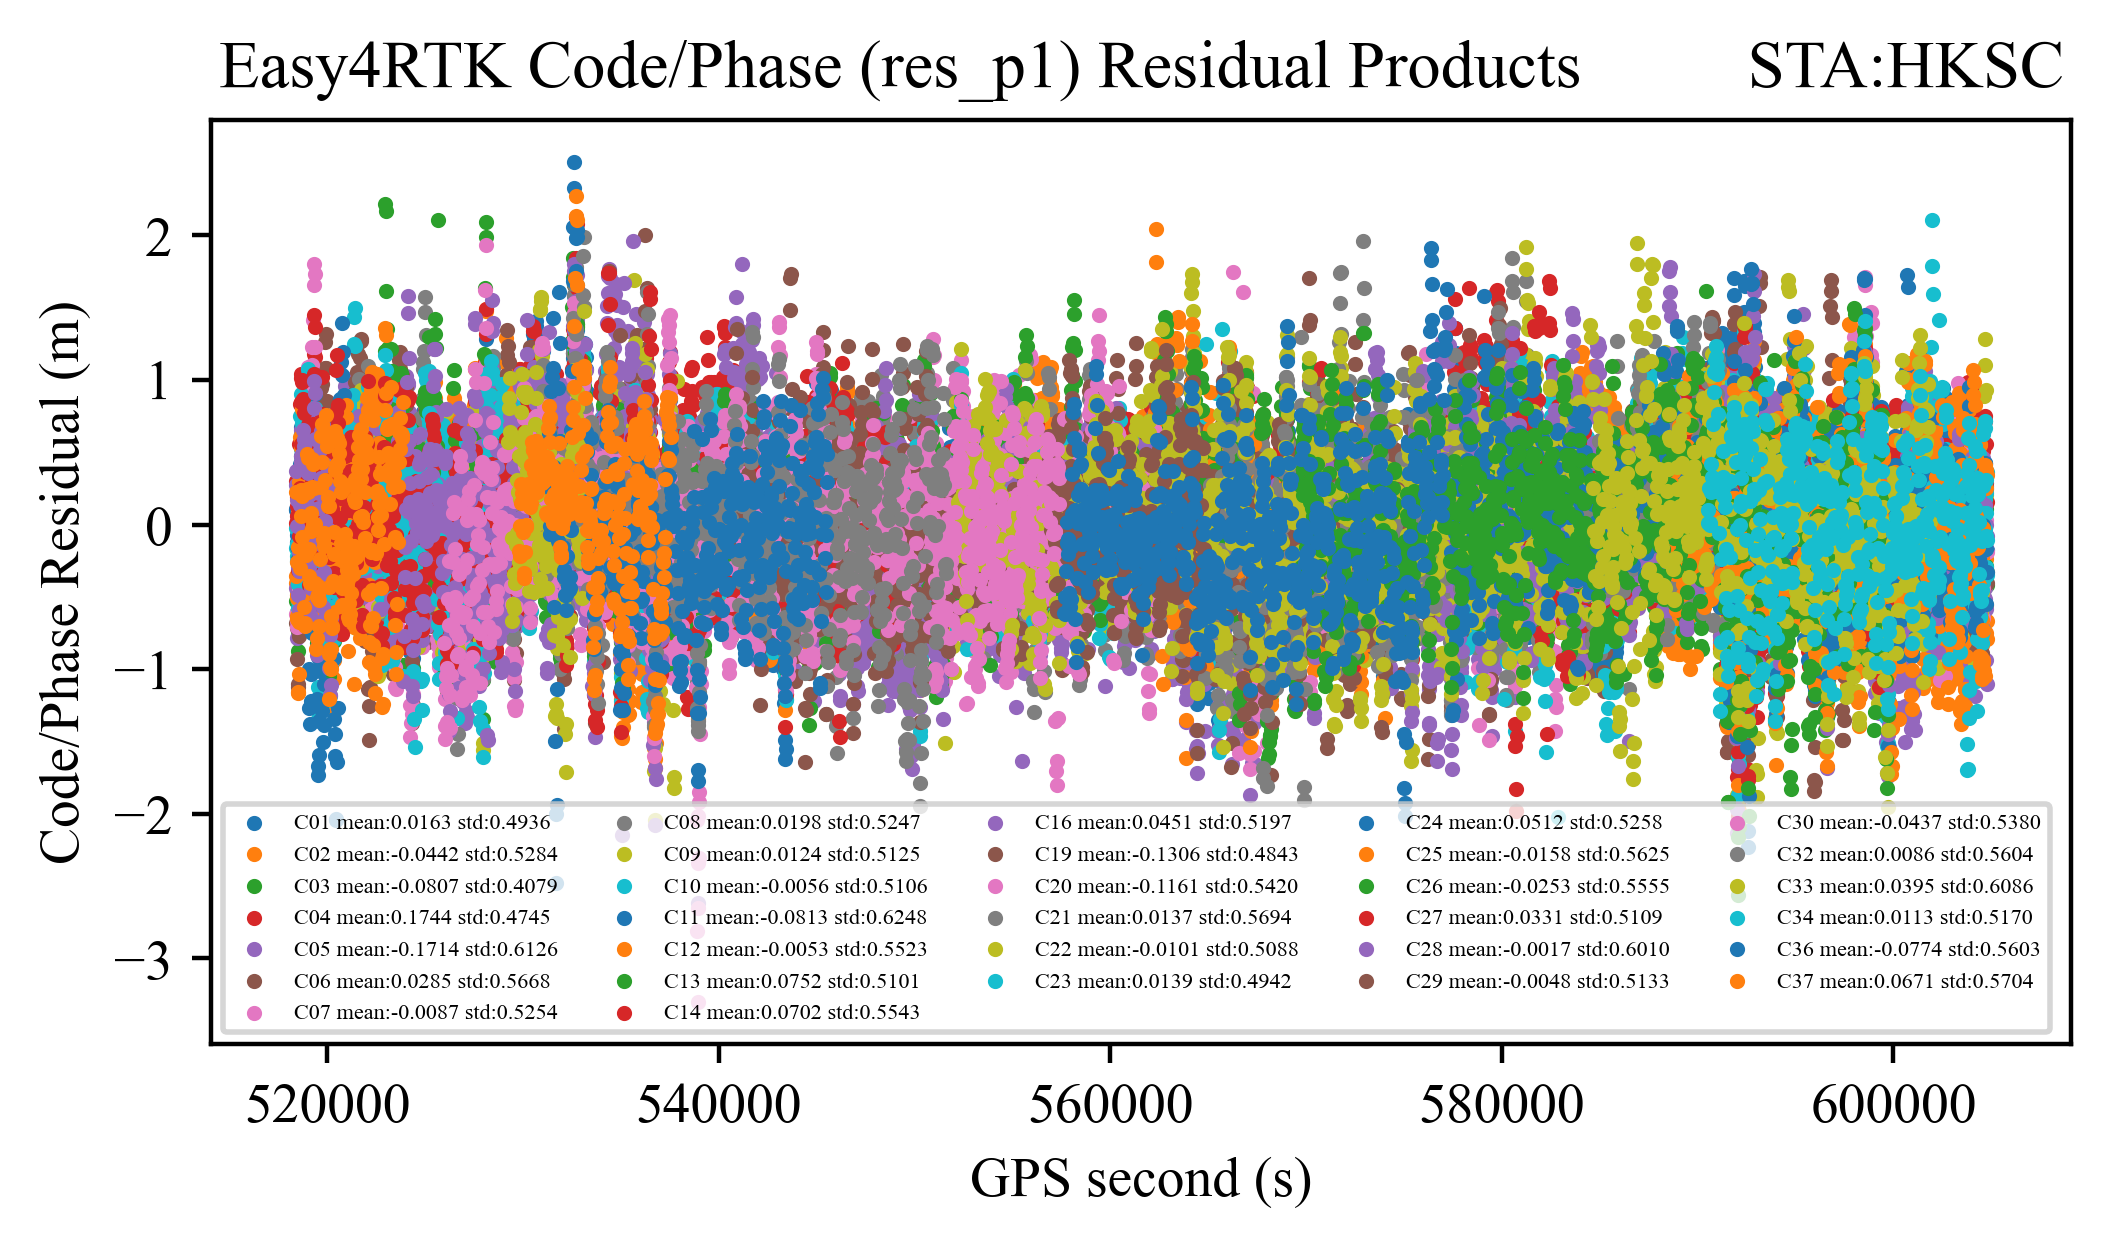

In [9]:
#绘图: 定位残差(NLOS误差)
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Times New Roman']

sys_name='C'        #系统标识符选择: G: GPS; C: BDS
sys_sat_num=65      #系统PRN码最大值: 此选项可限制绘图卫星的最大PRN范围
target='res_p1'     #残差归属: res_p1: 第一频率伪距; res_p2: 第二频率伪距; res_l1: 第一频率载波相位; res_l2: 第二频率载波相位
ylim=[]   #图像纵轴范围, 若空, 则由matplotlib自适应

target_prns=[]
legend=[]
plt.figure(dpi=400,facecolor="white",figsize=(6,3))
for PRN in range(1,sys_sat_num+1):
    PRN=sys_name+"{:02d}".format(PRN)
    stec_list=[]
    for out in sol_log:
        if(len(target_prns)==0):
            prns=list(out.keys())
        else:
            prns=target_prns.copy()
        if(PRN in prns and PRN in list(out.keys())):
                if(target in list(out[PRN].keys())):
                    GPSsec=out[PRN]['GPSsec']
                    stec_list.append([GPSsec,out[PRN][target]])
    
    if(len(stec_list)):
        plt.scatter(np.array(stec_list)[:,0],np.array(stec_list)[:,1],s=3)
        legend.append(PRN+' mean:{:.4f} std:{:.4f}'.format(np.mean(np.array(stec_list)[:,1]), np.std(np.array(stec_list)[:,1]) ) )

if(ylim!=[]):
    plt.ylim(ylim[0],ylim[1])

plt.ylabel("Code/Phase Residual (m)")
plt.xlabel("GPS second (s)")
plt.title("Easy4RTK Code/Phase ({}) Residual Products          STA:{}".format(target,STA_name))
plt.legend(legend,ncol=5,fontsize=4)